<div style="width: 100%; overflow: hidden;">
    <div style="width: 150px; float: left;"> <img src="data/D4Sci_logo_ball.png" alt="Data For Science, Inc" align="left" border="0"> </div>
    <div style="float: left; margin-left: 10px;"> <h1>Benchmarks</h1>
<h1>GGUF Generation: HC3 Prompts at Default Sampling</h1>
        <p>Bruno Gonçalves<br/>
        <a href="http://www.data4sci.com/">www.data4sci.com</a><br/>
            @bgoncalves, @data4sci</p></div>
</div>

In [1]:
import gc
import hashlib
import json
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import torch
import transformers
from huggingface_hub import hf_hub_download
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig

# vLLM exists only on the Linux install path. The try keeps the first-cell rule intact everywhere.
try:
    import vllm
    from vllm import LLM, SamplingParams
except ImportError:
    vllm = None

import watermark

%load_ext watermark

We start by print out the versions of the libraries we're using for future reference

In [2]:
%watermark -n -v -m -g -iv

Python implementation: CPython
Python version       : 3.14.6
IPython version      : 9.12.0

Compiler    : Clang 22.1.3 
OS          : Linux
Release     : 6.17.0-1026-nvidia
Machine     : aarch64
Processor   : aarch64
CPU cores   : 20
Architecture: 64bit

Git hash: f4f1589cdb1d01267b8945b8189ed68a75595728

huggingface_hub: 1.27.0
json           : 2.0.9
matplotlib     : 3.10.8
pandas         : 3.0.3
torch          : 2.11.0
tqdm           : 4.67.3
transformers   : 5.5.4
vllm           : 0.26.0
watermark      : 2.6.0



Load default figure style

In [3]:
plt.style.use('d4sci.mplstyle')
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

# Start

The fast sibling of `hc3_generation_benchmark.ipynb`: one pass per model over the HC3 prompts, at each model's own default sampling settings, one sample per prompt. No temperature sweep, no repeats, no figures — the deliverable is a single JSONL with every generation tagged by model, feeding the detector notebook directly. `prompt_idx` follows the same dedupe order as the benchmark notebook, so the human answers pair up identically. (`hc3_default_generation.py` is the headless twin of this notebook for unattended runs; both entry points share the same checkpoints and output files.)

Along the way, this notebook doubles as a tour of vLLM's offline inference API — the `LLM` class rather than the OpenAI-compatible server. Each section demonstrates one piece:

- **Loading a quantized GGUF** with a separately-specified Hugging Face tokenizer, and why the two travel as a pair.
- **Sizing the engine's memory** with `gpu_memory_utilization`, `max_num_seqs`, and `max_model_len` — including the KV-cache arithmetic that connects the three.
- **Chat templates**: turning a bare question into the token stream an instruction-tuned model was trained to complete.
- **Sampling** with `SamplingParams`, seeded for reproducibility, using each vendor's own defaults from `generation_config.json`.
- **Continuous batching**: handing `llm.generate` a thousand prompts at once and letting the scheduler keep the GPU saturated.
- **Prefix caching**, which lets every prompt reuse the KV blocks of the shared instruction prefix.
- **Teardown**: releasing one engine's memory so the next model can start.

The checkpoint/resume plumbing is not vLLM-specific, but it is what makes a multi-hour generation run safe to interrupt, so it gets explained too.

## Parameters

Same model list as the benchmark: seven single-file Q4_K_M GGUFs in the 7–9B class, each entry carrying its download repo, its file, and the base HF repo that supplies the tokenizer and chat template. Each model's sampling comes from its own `generation_config.json` on the Hub (temperature, top_p, top_k where the vendor set them, vLLM defaults otherwise), so every model generates the way its vendor intended.

`MAX_NEW = 1024` is headroom, not a target: the instruction asks for a 4-to-8-sentence paragraph, so nearly every answer ends at its EOS token long before the limit. The limit exists so a model that ignores the instruction (or rambles) cannot run a sequence to the `MAX_MODEL_LEN` ceiling — an earlier 256-token cap visibly truncated the long tail of answers, which is exactly what a detector would learn to key on.

**The memory model, in one paragraph.** vLLM pre-allocates at startup: `gpu_memory_utilization` names the fraction of device memory the engine may claim, and after loading weights and profiling activations it turns *all* of the remainder into KV cache, whether the workload can use it or not. The cache a workload can actually touch is bounded by concurrency × sequence length: at most `MAX_NUM_SEQS` sequences decode at once, each holding at most `MAX_MODEL_LEN` tokens of KV. Per token, a fp16 KV entry costs 2 (K and V) × n_layers × n_kv_heads × head_dim × 2 bytes. For Qwen2.5-7B (28 layers, 4 KV heads via grouped-query attention, head_dim 128) that is ~56 KB per token, so a full 1,536-token sequence holds ~86 MB and 256 concurrent sequences need ~22 GB. Add ~5 GB of weights and `GPU_UTIL = 0.35` (~42 GB of the Spark's 120 GB unified memory) covers it with room to spare — while leaving the rest of the machine alone. The one model that feels the cap is gemma-2-9b, whose fat KV layout (42 layers × 8 KV heads × head_dim 256 ≈ 336 KB per token) fits ~68 concurrent sequences in that budget — still deep enough to keep decode near saturation.

Two knobs deserve a second look because they interact with the scheduler rather than just memory. A tight `MAX_MODEL_LEN` is not only a safety bound: the scheduler admits sequences against the KV it can guarantee them, so a smaller ceiling lets it admit deeper decode batches from the same cache. And `CHECKPOINT_EVERY` chunks the work purely for crash safety — 1,000 prompts is still far above `MAX_NUM_SEQS`, so chunking costs no batch depth.

**Per-model engine routing.** The `engine` key on a spec exists because the vLLM GGUF plugin (0.0.5) loads only some architectures correctly — verified empirically with an engine start plus an output-coherence check per model. Only Qwen2.5 runs clean under vLLM. gemma-2 and Qwen3 fail on their tied lm_head, Mistral and Ministral on an unrecognized `model_type`, and Falcon3 and Yi-1.5 load but generate prompt-ignoring gibberish — Yi's failure was subtle enough to slip past the first coherence check: the engine starts fine and text streams out, but the outputs ignore the prompt and repeat the same noise motifs across prompts (a token/embedding mapping mismatch), while the detokenizer floods the log with "invalid prefix … resetting decode stream" warnings as the byte-level tokens it samples break the incremental decoder. Those six carry `"engine": "transformers"`, which dequantizes the *same* GGUF file — identical weights, HF's well-tested modeling code — and at batch 64 on cuda decodes within ~15% of vLLM (measured ~540 vs ~610 tok/s aggregate), because batched decode is memory-bandwidth-bound on either engine.

In [4]:
# Why per-model engines: the vLLM GGUF plugin (0.0.5) loads only some architectures
# correctly on this stack. Verified 2026-08-17/18 with engine start plus a coherence check:
# only Qwen2.5 generates clean text under vLLM; gemma-2 and Qwen3 fail on their tied
# lm_head, Mistral and Ministral on an unknown model_type, and Falcon3 and Yi-1.5 load but
# generate prompt-ignoring gibberish (Yi's outputs repeat the same noise motifs across
# prompts — a token/embedding mapping mismatch, and it also floods the log with
# detokenizer "invalid prefix" resets). Those six run under transformers instead, which
# dequantizes the same GGUF — identical weights, well-tested modeling code — and batch 64
# on cuda decodes within ~15% of vLLM here, since batched decode is memory-bandwidth-bound
# on either engine.
MODELS = [
    {"repo": "bartowski/Qwen2.5-7B-Instruct-GGUF",
     "file": "Qwen2.5-7B-Instruct-Q4_K_M.gguf",
     "tokenizer": "Qwen/Qwen2.5-7B-Instruct"},
    {"repo": "bartowski/gemma-2-9b-it-GGUF",
     "file": "gemma-2-9b-it-Q4_K_M.gguf",
     # Why this works gated: the account holds Gemma access, and HF_TOKEN travels
     # with every shell launched from the terminal.
     "tokenizer": "google/gemma-2-9b-it",
     "engine": "transformers"},
    {"repo": "bartowski/Mistral-7B-Instruct-v0.3-GGUF",
     "file": "Mistral-7B-Instruct-v0.3-Q4_K_M.gguf",
     "tokenizer": "mistralai/Mistral-7B-Instruct-v0.3",
     "engine": "transformers"},
    {"repo": "Qwen/Qwen3-8B-GGUF",
     "file": "Qwen3-8B-Q4_K_M.gguf",
     "tokenizer": "Qwen/Qwen3-8B",
     # Why thinking off: the template defaults to reasoning mode, and the detector
     # wants plain paragraph answers, not <think> traces.
     "template_kwargs": {"enable_thinking": False},
     "engine": "transformers"},
    {"repo": "bartowski/Ministral-8B-Instruct-2410-GGUF",
     "file": "Ministral-8B-Instruct-2410-Q4_K_M.gguf",
     "tokenizer": "mistralai/Ministral-8B-Instruct-2410",
     "engine": "transformers"},
    # {"repo": "bartowski/Yi-1.5-9B-Chat-GGUF",
    #  "file": "Yi-1.5-9B-Chat-Q4_K_M.gguf",
    #  "tokenizer": "01-ai/Yi-1.5-9B-Chat",
    #  "engine": "transformers"},
    {"repo": "bartowski/Falcon3-7B-Instruct-GGUF",
     "file": "Falcon3-7B-Instruct-Q4_K_M.gguf",
     "tokenizer": "tiiuae/Falcon3-7B-Instruct",
     "engine": "transformers"},
]

HC3_FILE       = "all.jsonl"
N_PROMPTS      = 10000
SEED           = 0                 # fixed seed keeps sampled runs reproducible
MAX_NEW        = 1024              # headroom, not a target — EOS ends answers well before this
MAX_MODEL_LEN  = 1536              # HC3 worst-case prompt is 404 tokens, + 1024 answer = 1428
GPU_UTIL       = 0.35              # small on purpose, see the note above
MAX_NUM_SEQS   = 256               # concurrency cap that sizes the KV cache actually used
FALLBACK_BATCH = None              # transformers batch size, None = 64 on cuda, 8 on mps and cpu
CHECKPOINT_EVERY = 1000            # prompts per chunk, bounds what an interruption can lose
RESUME         = True              # True picks an interrupted run back up, False starts over
RESULTS_DIR    = "results"
OUT_FILE       = "hc3_default_generations.jsonl"   # one combined file, model name on every row

## Pick the device and the engine

vLLM ships CUDA (and ROCm) kernels only, so it wins whenever a CUDA device is present — its continuous batching scheduler and paged KV cache are the reason this notebook finishes in minutes per model rather than hours. On MPS and CPU the notebook falls back to `transformers.generate`, which processes fixed batches with left-padding: the same GGUF gets dequantized on load, and the same records come out, just slower. Everything downstream is engine-blind — both branches expose one `run(prompts)` function. `ENGINE` is the machine-level default; a spec's `engine` key downgrades an individual model to transformers when the vLLM GGUF path can't load it.

In [5]:
if torch.cuda.is_available() and vllm is not None:
    DEVICE, ENGINE = "cuda", "vllm"
elif torch.cuda.is_available():
    DEVICE, ENGINE = "cuda", "transformers"
elif torch.backends.mps.is_available():
    DEVICE, ENGINE = "mps", "transformers"
else:
    DEVICE, ENGINE = "cpu", "transformers"

if FALLBACK_BATCH is None:
    FALLBACK_BATCH = {"cuda": 64, "mps": 8, "cpu": 8}[DEVICE]

print(f"device: {DEVICE} | engine: {ENGINE} | prompts: {N_PROMPTS:,} | models: {len(MODELS)}")

device: cuda | engine: vllm | prompts: 10,000 | models: 6


## Load HC3

HC3 (the Human ChatGPT Comparison Corpus) ships plain JSONL files, so a `hf_hub_download` plus `pd.read_json` replaces the datasets library entirely. Rows keep only questions with at least one human answer, which guarantees the detector a paired human text for every prompt. Selection and dedupe are identical to the benchmark notebook, so `prompt_idx` means the same thing in both output files and the detector pairs human answers without translation.

`INSTRUCTION` is the fixed wording prepended to every question. It shapes every generation — register, length, format — which is why it is recorded in the run metadata below and folded into the checkpoint fingerprint.

In [6]:
hc3_path = hf_hub_download(repo_id="Hello-SimpleAI/HC3",
                           filename=HC3_FILE, repo_type="dataset")
hd = pd.read_json(hc3_path, lines=True)
hd["question"] = hd.question.fillna("").str.strip()
hd = hd[(hd.question.str.len() > 0) & (hd.human_answers.str.len() > 0)]

pairs = hd.drop_duplicates(subset=["question"]).reset_index(drop=True)
pairs = pairs.head(min(N_PROMPTS, len(pairs)))
print(f"rows: {len(hd):,} | unique questions used: {len(pairs):,} | "
      f"domains: {dict(pairs.source.value_counts())}")

INSTRUCTION = ("Answer the question in one clear paragraph of 4 to 8 sentences. "
               "Write for a general reader.")

rows: 24,322 | unique questions used: 10,000 | domains: {'reddit_eli5': np.int64(10000)}


## Model helpers

`resolve_model` prefers a local `path` when the spec names one and downloads from the Hub otherwise — `hf_hub_download` caches under `~/.cache/huggingface`, so repeated runs never re-download. `fast_hash` fingerprints a 5 GB file in under a second by hashing the first and last 16 MB plus the size; it keys the checkpoints and tags every output row, so generations stay attributable to an exact model file even if a repo re-uploads.

In [7]:
def resolve_model(spec):
    if spec.get("path") and Path(spec["path"]).exists():
        return Path(spec["path"])
    print(f"downloading {spec['file']} from {spec['repo']}")
    return Path(hf_hub_download(repo_id=spec["repo"], filename=spec["file"]))

def fast_hash(path, chunk=16 * 1024 * 1024):
    h = hashlib.sha256()
    size = path.stat().st_size
    with open(path, "rb") as f:
        h.update(f.read(chunk))
        if size > 2 * chunk:
            f.seek(-chunk, 2)
            h.update(f.read(chunk))
    h.update(str(size).encode())
    return h.hexdigest()[:12]

### Each model's default sampling

Sampling settings are part of a model's identity: Qwen ships `temperature 0.7, top_p 0.8, top_k 20` in its `generation_config.json`, most others ship nothing and mean plain `temperature 1.0` sampling. `GenerationConfig.from_pretrained` fetches that file, and `to_diff_dict()` is the important detail — it returns only what the vendor actually wrote, so transformers' own library defaults (like `top_k=50`) never masquerade as a model's choice. Whatever is unset stays at the neutral value, which matches vLLM's `SamplingParams` defaults exactly: `temperature=1.0`, `top_p=1.0`, and `top_k=-1` meaning "no top-k filtering".

In [8]:
def default_sampling(repo):
    # Why to_diff_dict: it holds only what the vendor wrote into generation_config.json,
    # so library fallbacks (like transformers' own top_k=50) never masquerade as a
    # model default. Anything unset stays at the neutral value.
    out = {"temperature": 1.0, "top_p": 1.0, "top_k": -1}
    try:
        cfg = GenerationConfig.from_pretrained(repo).to_diff_dict()
    except Exception as e:
        print(f"no generation config for {repo} ({e}), using temperature 1.0")
        return out
    for key in ("temperature", "top_p", "top_k"):
        if cfg.get(key) is not None:
            out[key] = cfg[key]
    return out

## Prompts through the chat template

An instruction-tuned model was trained on conversations rendered in a specific plain-text format — role markers, turn separators, an end-of-turn token — and it completes that format, not raw text. `apply_chat_template` renders a message list into exactly that layout using the Jinja template stored with the tokenizer, and `add_generation_prompt=True` appends the assistant header so the model's first token is the start of its answer. This is why the tokenizer repo travels with the GGUF: the quantized file holds weights, but the template that makes prompts well-formed lives with the tokenizer.

Two practical notes. `template_kwargs` passes model-specific template switches — Qwen3's template defaults to reasoning mode, and `enable_thinking=False` turns the `<think>` preamble off so the detector gets plain paragraph answers rather than reasoning traces. And the token-length assert is the contract with `MAX_MODEL_LEN`: every prompt must fit with `MAX_NEW` tokens of headroom, because vLLM will refuse (or truncate) requests that cannot fit the sequence budget.

In [9]:
def render_prompts(spec, tok):
    def build(question):
        # Why the cap: a few finance and medicine questions run very long, and 2,000
        # characters keeps every prompt inside MAX_MODEL_LEN with room for the answer.
        user = f"{INSTRUCTION}\n\nQuestion: {question[:2000]}"
        return tok.apply_chat_template(
            [{"role": "user", "content": user}],
            tokenize=False, add_generation_prompt=True,
            **spec.get("template_kwargs", {}))

    prompt_texts = [build(q) for q in pairs.question]
    lens = [len(ids) for ids in tok(prompt_texts).input_ids]
    assert max(lens) + MAX_NEW <= MAX_MODEL_LEN, "raise MAX_MODEL_LEN"
    return prompt_texts

## Start the engine

The `LLM` constructor is the whole offline API surface. What each argument does here:

- `model` points straight at the GGUF file; on this machine a loader plugin registers the `gguf` load format and vLLM runs the quantized weights with native Q4_K_M kernels — no dequantization.
- `tokenizer` overrides the GGUF's embedded tokenizer metadata with the base HF repo, keeping tokenization and the chat template authoritative.
- `max_model_len`, `gpu_memory_utilization`, and `max_num_seqs` implement the memory plan from the Parameters section.
- `enable_prefix_caching=True` turns on block-level KV reuse: vLLM hashes each block of prompt tokens, and since every prompt here opens with the same instruction text, later prompts skip prefill for those shared blocks. (The benchmark notebook turns this *off*, because a warm cache would flatter every timed run after the first — a good example of a knob whose right setting depends on whether you're measuring or producing.)

Construction is where the heavy lifting happens, and the startup log is worth reading once: the engine core starts as a separate process, loads weights (~7 GB here), captures CUDA graphs for a ladder of batch sizes, then prints exactly how it spent its memory budget and how many KV tokens fit — including the maximum concurrency it can sustain at this `max_model_len`.

`run(prompts)` wraps `llm.generate`. Continuous batching means this one call does everything: prompts are prefilled in chunks alongside ongoing decodes, sequences that finish free their KV blocks immediately for waiting prompts, and the GPU stays saturated without any batching logic on our side. The returned `RequestOutput` list is in input order; each holds `prompt_token_ids` and `n` completions under `.outputs`, with token ids and detokenized text. `SamplingParams` carries the per-model defaults plus `max_tokens` and a fixed `seed` so a rerun of the same chunk reproduces the same samples.

The transformers fallback implements the same `run` contract with left-padded fixed batches — decoder-only models append on the right, so padding must sit on the left to keep rows aligned.

`start_engine` takes the *effective* engine for this model — the machine default unless the spec downgrades to transformers. On the transformers path the dtype is bfloat16 on cuda rather than float16: gemma-2's logit soft-capping produces values that overflow float16's range, and bfloat16 keeps float32's exponent.

In [10]:
def start_engine(model_path, spec, tok, sampling, eng):
    if eng == "vllm":
        llm = LLM(
            model=str(model_path),
            tokenizer=spec["tokenizer"],
            max_model_len=MAX_MODEL_LEN,
            gpu_memory_utilization=GPU_UTIL,
            max_num_seqs=MAX_NUM_SEQS,
            # Why prefix caching on: this is generation, not a benchmark, and every
            # prompt shares the instruction prefix — a free head start on prefill.
            enable_prefix_caching=True,
        )

        def run(prompts):
            sp = SamplingParams(max_tokens=MAX_NEW, n=1, seed=SEED, **sampling)
            outs = llm.generate(prompts, sp)
            gens = []
            for pi, o in enumerate(outs):
                seq = o.outputs[0]
                gens.append((pi, len(seq.token_ids), seq.text.strip()))
            return gens

        return run, llm, vllm.__version__

    # Why bfloat16 on cuda: gemma-2's logit soft-capping overflows float16.
    # mps runs float16 well, cpu wants float32.
    dt = {"cuda": torch.bfloat16, "mps": torch.float16, "cpu": torch.float32}[DEVICE]
    # transformers dequantizes the GGUF on load, so memory equals params times dtype size.
    model = AutoModelForCausalLM.from_pretrained(
        str(model_path.parent), gguf_file=model_path.name, torch_dtype=dt
    ).to(DEVICE).eval()

    # Why left padding: decoder-only generation appends on the right,
    # so padding must sit on the left to keep every row aligned.
    tok.padding_side = "left"
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    def run(prompts):
        torch.manual_seed(SEED)
        kwargs = dict(max_new_tokens=MAX_NEW, pad_token_id=tok.pad_token_id)
        if sampling["temperature"] > 0:
            kwargs.update(do_sample=True, temperature=sampling["temperature"],
                          top_p=sampling["top_p"],
                          top_k=sampling["top_k"] if sampling["top_k"] > 0 else 0)
        else:
            kwargs.update(do_sample=False)

        gens = []
        # Why leave=False: one transient bar per chunk, so the chunk log stays clean.
        for i in tqdm(range(0, len(prompts), FALLBACK_BATCH),
                      desc=f"batches of {FALLBACK_BATCH}", leave=False):
            batch = prompts[i:i + FALLBACK_BATCH]
            enc = tok(batch, return_tensors="pt", padding=True).to(DEVICE)
            with torch.no_grad():
                out = model.generate(**enc, **kwargs)
            gen = out[:, enc.input_ids.shape[1]:]
            for j in range(gen.shape[0]):
                row = gen[j]
                n_t = int((row != tok.pad_token_id).sum())
                gens.append((i + j, n_t, tok.decode(row, skip_special_tokens=True).strip()))
        return gens

    return run, model, transformers.__version__

## Output artifacts and resume bookkeeping

Three files live next to the generations: the combined JSONL itself, a `.done.json` listing the model hashes already appended to it, and a `.meta.json` sidecar recording the exact prompt wording and run configuration. The sidecar exists because the instruction text shapes every generation, so it belongs in the artifacts — but repeating it on every row would bloat the JSONL with a constant.

In [11]:
out_dir = Path(RESULTS_DIR)
out_dir.mkdir(exist_ok=True)
ckpt_dir = out_dir / "checkpoints"
ckpt_dir.mkdir(parents=True, exist_ok=True)

out_path = out_dir / OUT_FILE
done_path = out_dir / (OUT_FILE + ".done.json")
meta_path = out_dir / (OUT_FILE.replace(".jsonl", "") + ".meta.json")
done_models = set(json.loads(done_path.read_text())) if RESUME and done_path.exists() else set()
if not RESUME:
    out_path.unlink(missing_ok=True)
    done_path.unlink(missing_ok=True)

In [12]:
meta_path.write_text(json.dumps({
    "instruction": INSTRUCTION,
    "prompt_template": "{INSTRUCTION}\\n\\nQuestion: {question[:2000]} -> chat template, add_generation_prompt=True",
    "dataset": {"name": "Hello-SimpleAI/HC3", "file": HC3_FILE,
                "n_prompts": len(pairs), "dedupe": "drop_duplicates(question), head"},
    "engine": ENGINE, "device": DEVICE, "seed": SEED,
    "max_new_tokens": MAX_NEW, "max_model_len": MAX_MODEL_LEN,
    "sampling": "per-model generation_config.json defaults, recorded on each row",
}, indent=2))

566

### Checkpoint files

Each model sweeps against its own checkpoint pair, named by a fingerprint of everything that determines the output: model hash, corpus, prompt count, sampling, seed, token limits, engine, and the instruction wording. Change any of those and the fingerprint changes, so a resumed run can never silently mix generations from two different configurations. The memory knobs (`GPU_UTIL`, `MAX_NUM_SEQS`) stay out of the fingerprint on purpose — retuning them mid-scan must not throw away finished chunks, since neither changes what gets generated.

On resume, finished chunks reload from the checkpoint JSONL, keyed by `prompt_idx` with last-write-wins — that drops duplicates left by a crash that landed generations but not state.

In [13]:
def open_checkpoint(model_hash, sampling, eng):
    # Why INSTRUCTION is in here: a wording change changes every generation, so it must
    # start fresh checkpoints, exactly like a knob that alters what gets sampled.
    fingerprint = hashlib.sha256(json.dumps(
        [model_hash, HC3_FILE, N_PROMPTS, sampling, SEED, MAX_NEW,
         MAX_MODEL_LEN, eng, DEVICE, INSTRUCTION]).encode()).hexdigest()[:12]
    gens_path = ckpt_dir / f"ckpt_default__{fingerprint}.generations.jsonl"
    state_path = ckpt_dir / f"ckpt_default__{fingerprint}.state.json"

    if RESUME and state_path.exists():
        state = json.loads(state_path.read_text())
        print(f"resuming checkpoint {fingerprint}: {len(state['chunks'])} chunks already done")
    else:
        state = {"chunks": {}}
        gens_path.unlink(missing_ok=True)
        state_path.unlink(missing_ok=True)

    # Records from finished chunks reload here, last-write-wins on prompt_idx to drop
    # duplicates left by a crash that landed generations but not state.
    done = {}
    if gens_path.exists():
        with open(gens_path) as f:
            for line in f:
                try:
                    r = json.loads(line)
                except json.JSONDecodeError:   # partial last line from an interrupted write
                    continue
                if r["chunk"] in state["chunks"]:
                    done[r["prompt_idx"]] = r
    return gens_path, state_path, state, done

### The chunked sweep

Chunks of `CHECKPOINT_EVERY` prompts run through the engine one at a time. A finished chunk appends its rows to the checkpoint JSONL **and then** records itself in the state file, in that order: a chunk only counts once its samples are on disk, so a crash between the two writes costs one redone chunk, never data. The state file is written atomically (temp file + rename) so it can never be half-written.

In [14]:
def sweep_model(run, prompt_texts, model_name, model_hash, sampling, eng,
                gens_path, state_path, state, done):
    for c, start in enumerate(range(0, len(prompt_texts), CHECKPOINT_EVERY)):
        key = f"c{c}"
        if key in state["chunks"]:
            continue
        t0 = time.time()
        gens = run(prompt_texts[start:start + CHECKPOINT_EVERY])
        wall = time.time() - t0
        # Why generations before state: a chunk only counts once its samples are on
        # disk, so a crash between the two writes costs one redone chunk, never data.
        with open(gens_path, "a") as f:
            for pi, n_t, text in gens:
                rec = {"chunk": key,
                       "model": model_name, "model_hash": model_hash, "engine": eng,
                       **sampling,
                       "prompt_idx": start + pi, "out_tokens": n_t, "text": text}
                f.write(json.dumps(rec) + "\n")
                done[start + pi] = rec
        state["chunks"][key] = {"wall_s": wall, "n_generations": len(gens)}
        tmp = state_path.with_suffix(".tmp")
        tmp.write_text(json.dumps(state))
        tmp.replace(state_path)
        n_done = min(start + CHECKPOINT_EVERY, len(prompt_texts))
        print(f"  chunk {key} | {wall:6.1f} s | {n_done:,}/{len(prompt_texts):,} prompts")

### Finalizing a model

When a model's last chunk lands, its deduped rows append to the combined output in prompt order, the model's hash joins the done-list, and the checkpoint pair retires. A restart then skips the model entirely on the hash check — the checkpoint machinery only ever engages for the model that was actually interrupted.

In [15]:
def finalize_model(model_hash, done, gens_path, state_path):
    with open(out_path, "a") as f:
        for pi in sorted(done):
            r = done[pi]
            r.pop("chunk", None)
            f.write(json.dumps(r) + "\n")
    done_models.add(model_hash)
    tmp = done_path.with_suffix(".tmp")
    tmp.write_text(json.dumps(sorted(done_models)))
    tmp.replace(done_path)
    gens_path.unlink(missing_ok=True)
    state_path.unlink(missing_ok=True)

## Run the scan

The driver loop is now just the story in order: resolve and fingerprint the model, skip it if it already finished, fetch its default sampling, render the prompts, start the engine, warm up, sweep with checkpoints, finalize, tear down.

Two details worth noting. The warmup call absorbs one-time costs that would otherwise land in the first chunk's timing — kernel autotuning and allocator growth on top of the graph capture that already happened at construction. And teardown is how one process runs seven engines in sequence: dropping the last references to the `LLM` object shuts down the engine-core process and releases its entire pre-allocated block, `gc.collect()` makes that deterministic instead of whenever-the-GC-runs, and `torch.cuda.empty_cache()` returns whatever the caching allocator still holds. Skip this and the second model's constructor would find the memory budget already spent.

In [16]:
scan_t0 = time.time()
for spec in MODELS:
    model_path = resolve_model(spec)
    model_hash = fast_hash(model_path)
    model_name = model_path.stem
    if model_hash in done_models:
        print(f"skipping {model_name}: already in {out_path.name}")
        continue

    sampling = default_sampling(spec["tokenizer"])
    # A spec's engine override only means something where vLLM is an option at all.
    eng = "transformers" if ENGINE == "transformers" else spec.get("engine", ENGINE)
    print(f"\n{'=' * 70}\n{model_name} | hash {model_hash} | engine {eng} "
          f"| default sampling: {sampling}")

    tok = AutoTokenizer.from_pretrained(spec["tokenizer"])
    prompt_texts = render_prompts(spec, tok)

    run, engine, engine_version = start_engine(model_path, spec, tok, sampling, eng)
    print(f"{eng} {engine_version} ready on {DEVICE}")
    run(prompt_texts[:min(8, len(prompt_texts))])   # warmup, untimed

    gens_path, state_path, state, done = open_checkpoint(model_hash, sampling, eng)

    model_t0 = time.time()
    sweep_model(run, prompt_texts, model_name, model_hash, sampling, eng,
                gens_path, state_path, state, done)
    finalize_model(model_hash, done, gens_path, state_path)

    wall = time.time() - model_t0
    # Why a runtimes sidecar: chunk timings retire with the checkpoint, so this is the
    # only durable record of what each model cost. wall_s covers this process's share
    # only — chunks inherited from an interrupted run were paid for by that run.
    with open(out_dir / (OUT_FILE.replace(".jsonl", "") + ".runtimes.jsonl"), "a") as f:
        f.write(json.dumps({
            "model": model_name, "model_hash": model_hash, "engine": eng,
            "wall_s": round(wall, 1), "n_generations": len(done),
            "output_tokens": sum(r["out_tokens"] for r in done.values()),
            "finished_at": time.strftime("%Y-%m-%d %H:%M:%S")}) + "\n")
    print(f"{model_name} done: {len(done):,} generations in {wall/60:.1f} min "
          f"-> {out_path.name}")

    # ---- Tear the engine down so the next model gets the memory back ----
    del engine, run, tok
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

print(f"\nscan complete: {len(done_models)}/{len(MODELS)} models "
      f"in {(time.time() - scan_t0)/3600:.1f} h | output: {out_path}")

downloading Qwen2.5-7B-Instruct-Q4_K_M.gguf from bartowski/Qwen2.5-7B-Instruct-GGUF
skipping Qwen2.5-7B-Instruct-Q4_K_M: already in hc3_default_generations.jsonl
downloading gemma-2-9b-it-Q4_K_M.gguf from bartowski/gemma-2-9b-it-GGUF
skipping gemma-2-9b-it-Q4_K_M: already in hc3_default_generations.jsonl
downloading Mistral-7B-Instruct-v0.3-Q4_K_M.gguf from bartowski/Mistral-7B-Instruct-v0.3-GGUF
skipping Mistral-7B-Instruct-v0.3-Q4_K_M: already in hc3_default_generations.jsonl
downloading Qwen3-8B-Q4_K_M.gguf from Qwen/Qwen3-8B-GGUF
skipping Qwen3-8B-Q4_K_M: already in hc3_default_generations.jsonl
downloading Ministral-8B-Instruct-2410-Q4_K_M.gguf from bartowski/Ministral-8B-Instruct-2410-GGUF
skipping Ministral-8B-Instruct-2410-Q4_K_M: already in hc3_default_generations.jsonl
downloading Falcon3-7B-Instruct-Q4_K_M.gguf from bartowski/Falcon3-7B-Instruct-GGUF
skipping Falcon3-7B-Instruct-Q4_K_M: already in hc3_default_generations.jsonl

scan complete: 6/6 models in 0.0 h | output: re

## A first look at the output

One combined file, one row per generation, model name and sampling settings on every row — so a groupby tells the scan's whole story, and any row can be traced back to its HC3 question via `prompt_idx`.

In [17]:
if out_path.exists():
    sample = pd.read_json(out_path, lines=True)
    print(sample.groupby("model")
                .agg(rows=("text", "size"), temperature=("temperature", "first"),
                     mean_out_tokens=("out_tokens", "mean")).round(1))
    print("\nfirst generation:\n", sample.iloc[0].text[:400])

                                    rows  temperature  mean_out_tokens
model                                                                 
Falcon3-7B-Instruct-Q4_K_M         10000          1.0            140.6
Ministral-8B-Instruct-2410-Q4_K_M  10000          1.0            148.2
Mistral-7B-Instruct-v0.3-Q4_K_M    10000          1.0            176.2
Qwen2.5-7B-Instruct-Q4_K_M         10000          0.7            144.5
Qwen3-8B-Q4_K_M                    10000          0.6            141.7
gemma-2-9b-it-Q4_K_M               10000          1.0            143.9

first generation:
 Imagine you have a big toy box where all your friends keep their favorite toys. Now, every week, you and your friends count how many toys each person has in their box. Sometimes, one friend might have the most toys, but other times, there might be two or three friends with the most toys. The New York Times Best Sellers list is like that toy box, but for books. It doesn't just show one book at the 


### Scan progress at a glance

Two panels straight off the combined output: completed generations per model — each bar annotated with engine, wall time, and aggregate decode throughput — and the output-length distribution per finished model against the `MAX_NEW` ceiling (a safety limit, not a target — answers end at EOS, so the boxes should sit well left of it). Wall time and tok/s prefer the exact records in the `.runtimes.jsonl` sidecar and fall back to the decode rates measured on this machine (vLLM ≈610 tok/s, transformers ≈540 tok/s), with the ≈ prefix marking estimated values. The figure also lands in `hc3_default_scan_progress.png` so a partial scan can be reported without re-running the notebook.

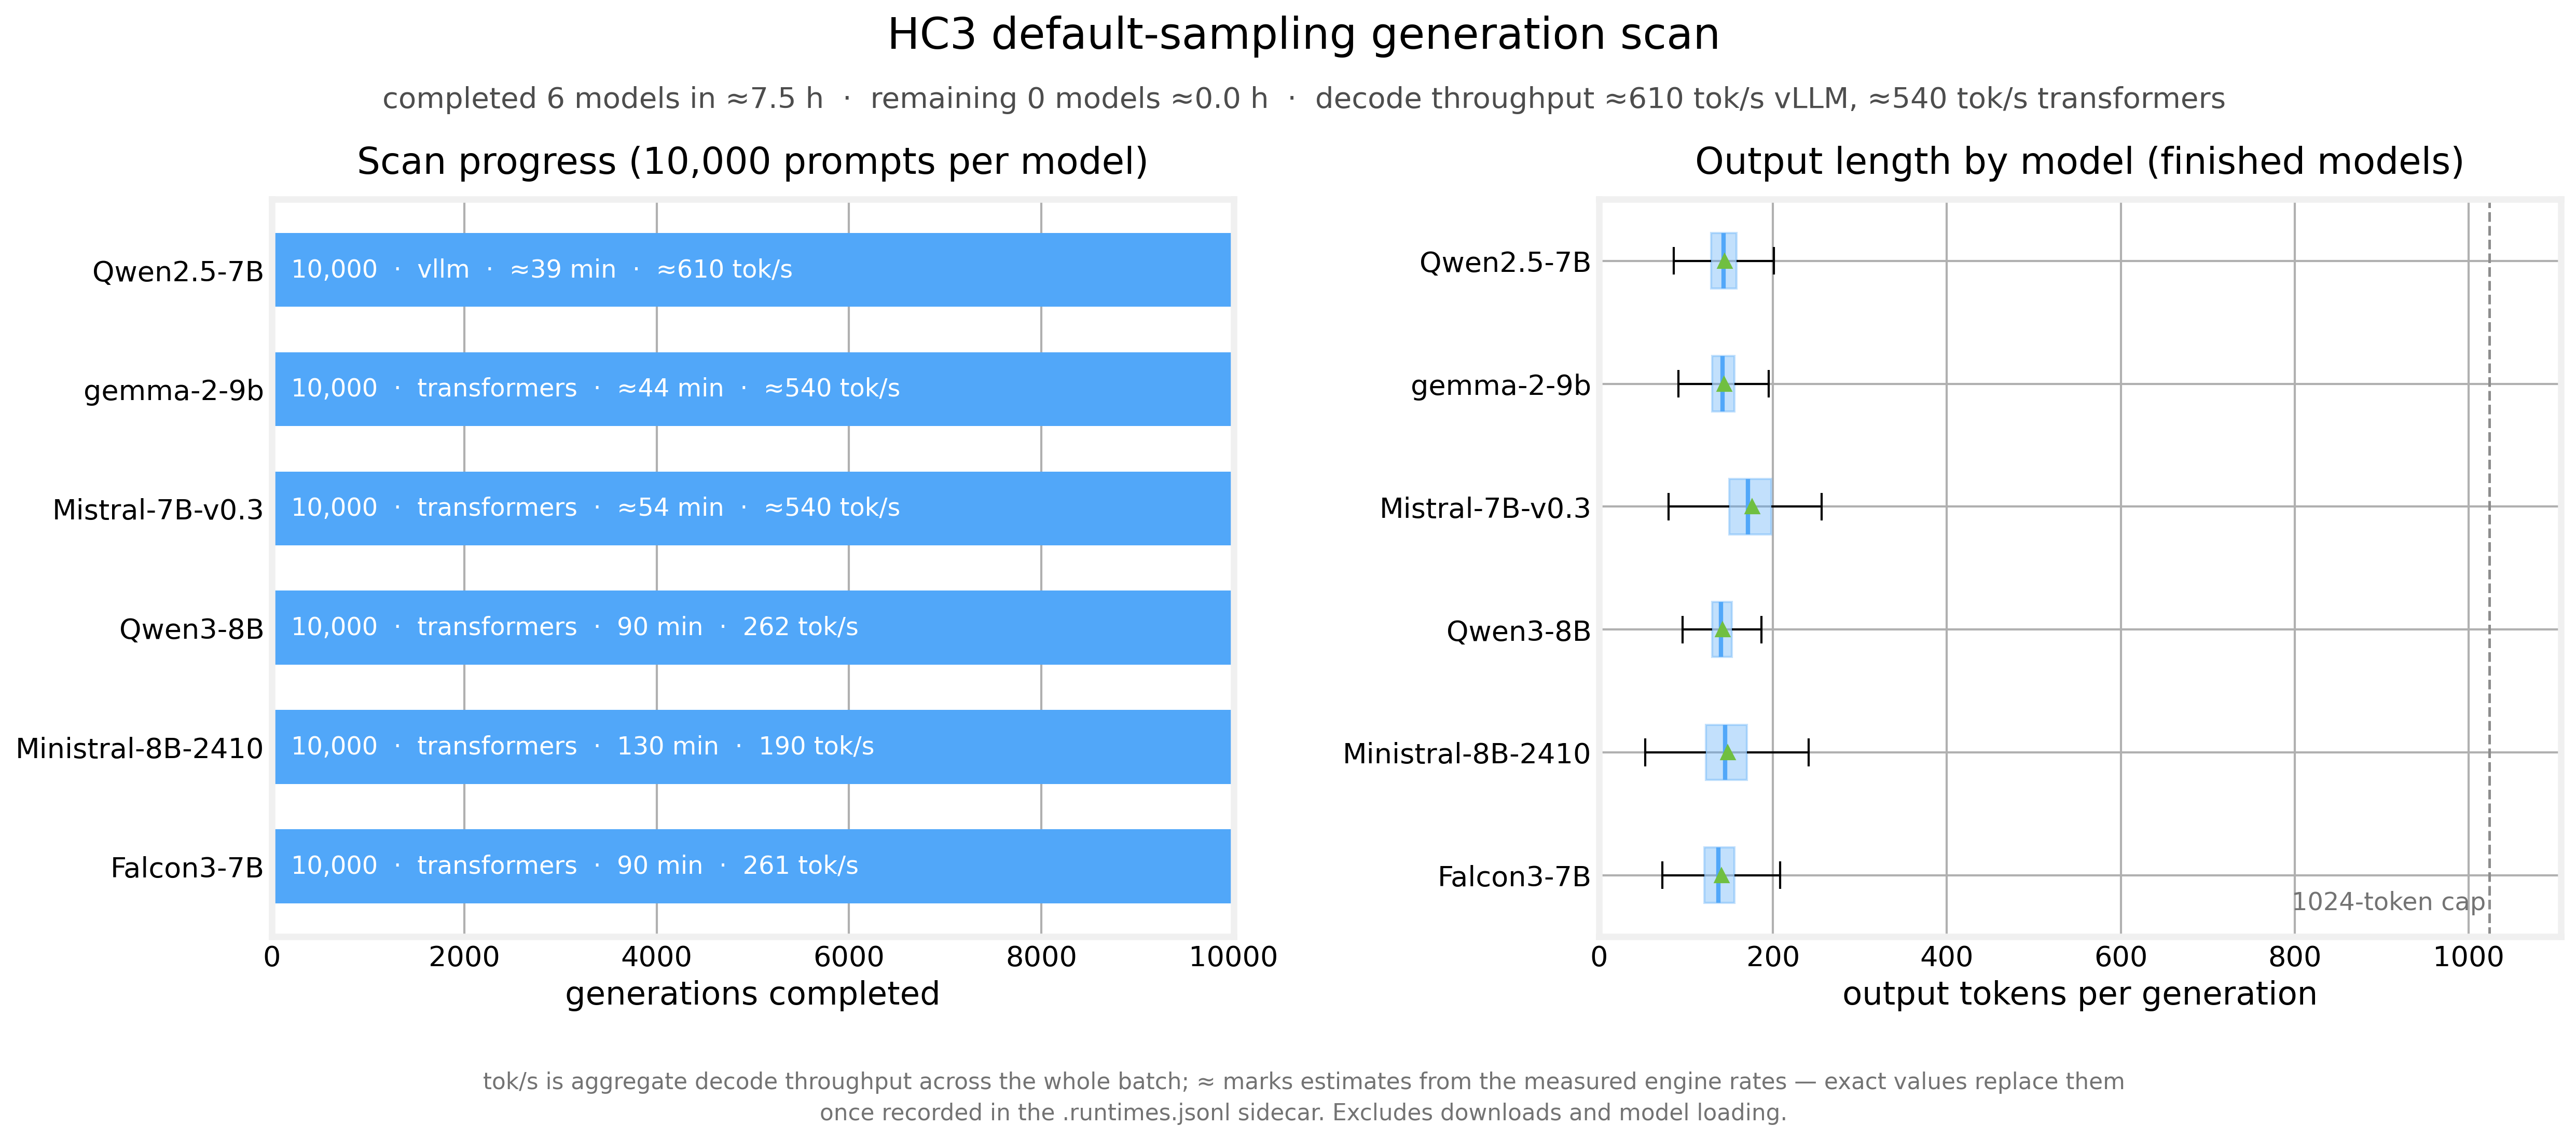

In [20]:
if out_path.exists():
    TPUT = {"vllm": 610.0, "transformers": 540.0}   # measured aggregate decode tok/s on this machine

    order = [s["file"].replace(".gguf", "") for s in MODELS]
    short = {m: m.replace("-Q4_K_M", "").replace("-Instruct", "").replace("-it", "")
                .replace("-Chat", "") for m in order}
    eng = {s["file"].replace(".gguf", ""):
           ("transformers" if ENGINE == "transformers" else s.get("engine", ENGINE))
           for s in MODELS}

    gen = pd.read_json(out_path, lines=True)
    counts = gen.groupby("model").size().to_dict()
    toks = gen.groupby("model").out_tokens.apply(list).to_dict()

    # Exact runtimes where the sidecar has them, throughput-backed estimates otherwise.
    runt_path = out_dir / (OUT_FILE.replace(".jsonl", "") + ".runtimes.jsonl")
    measured = {}
    if runt_path.exists():
        with open(runt_path) as f:
            for line in f:
                r = json.loads(line)
                measured[r["model"]] = {"min": r["wall_s"] / 60,
                                        "tps": r["output_tokens"] / r["wall_s"]}

    def stats(m):
        if m in measured:
            return measured[m]["min"], measured[m]["tps"], True
        return sum(toks[m]) / TPUT[eng[m]] / 60, TPUT[eng[m]], False

    done = [m for m in order if counts.get(m)]
    pending = [m for m in order if not counts.get(m)]
    total_done = sum(stats(m)[0] for m in done)
    avg_tok = gen.out_tokens.mean()
    total_rem = sum(N_PROMPTS * avg_tok / TPUT[eng[m]] / 60 for m in pending)

    TITLE, LABEL, TICK, ANN = 17, 15, 13, 11.5
    # Why autolayout off: the house style turns tight_layout on at every draw, which
    # cannot handle this axes mix and would override the explicit margins below.
    plt.rcParams["figure.autolayout"] = False
    fig, axes = plt.subplots(1, 2, figsize=(17, 7.4), gridspec_kw={"wspace": 0.38})

    names = [short[m] for m in order][::-1]
    vals = [counts.get(m, 0) for m in order][::-1]
    ypos = range(len(order))
    axes[0].barh(ypos, [N_PROMPTS] * len(order), color="0.92", height=0.62, zorder=1)
    axes[0].barh(ypos, vals, color=colors[0], height=0.62, zorder=2)
    axes[0].set_yticks(list(ypos))
    axes[0].set_yticklabels(names, fontsize=TICK)
    for yi, (m, v) in zip(ypos, zip(order[::-1], vals)):
        if v:
            mins, tps, exact = stats(m)
            p = "" if exact else "\u2248"
            label, color = f"{v:,}  \u00b7  {eng[m]}  \u00b7  {p}{mins:.0f} min  \u00b7  {p}{tps:.0f} tok/s", "white"
        else:
            label, color = "pending", "0.45"
        axes[0].text(0.02 * N_PROMPTS, yi, label, va="center", ha="left",
                     fontsize=ANN, color=color, zorder=3)
    axes[0].set_xlim(0, N_PROMPTS)
    axes[0].tick_params(axis="x", labelsize=TICK)
    axes[0].set_xlabel("generations completed", fontsize=LABEL)
    axes[0].set_title(f"Scan progress ({N_PROMPTS:,} prompts per model)", fontsize=TITLE, pad=12)

    bp = axes[1].boxplot([toks[m] for m in done], vert=False, showmeans=True, widths=0.45,
                         tick_labels=[short[m] for m in done],
                         patch_artist=True, showfliers=False)
    for box in bp["boxes"]:
        box.set(facecolor=colors[0], alpha=0.35, edgecolor=colors[0])
    for med in bp["medians"]:
        med.set(color=colors[0], linewidth=2)
    axes[1].axvline(MAX_NEW, ls="--", color="0.55", lw=1.2)
    axes[1].text(MAX_NEW - 4, len(done) + 0.28, f"{MAX_NEW}-token cap",
                 fontsize=ANN, color="0.45", ha="right")
    axes[1].invert_yaxis()
    axes[1].tick_params(labelsize=TICK)
    axes[1].set_xlim(0, MAX_NEW * 1.08)
    axes[1].set_xlabel("output tokens per generation", fontsize=LABEL)
    axes[1].set_title("Output length by model (finished models)", fontsize=TITLE, pad=12)

    fig.suptitle("HC3 default-sampling generation scan", fontsize=20, y=0.975)
    # Why inside the canvas: text placed below the figure bounds survives savefig with a
    # tight bbox but is clipped by inline renderers that use the figure's own bounds.
    fig.text(0.5, 0.895, (
        f"completed {len(done)} models in \u2248{total_done/60:.1f} h  \u00b7  "
        f"remaining {len(pending)} models \u2248{total_rem/60:.1f} h  \u00b7  "
        f"decode throughput \u2248{TPUT['vllm']:.0f} tok/s vLLM, "
        f"\u2248{TPUT['transformers']:.0f} tok/s transformers"),
        ha="center", fontsize=13.5, color="0.3")
    fig.text(0.5, 0.012, (
        "tok/s is aggregate decode throughput across the whole batch; \u2248 marks estimates from the "
        "measured engine rates \u2014 exact values replace them\n"
        "once recorded in the .runtimes.jsonl sidecar. Excludes downloads and model loading."),
        ha="center", va="bottom", fontsize=10.5, color="0.45", linespacing=1.5)
    # Why explicit margins: tight_layout refuses this axes mix, and the figure-level
    # header and footer text need reserved bands that it would not respect anyway.
    fig.subplots_adjust(left=0.11, right=0.975, top=0.815, bottom=0.175, wspace=0.33)
    fig.savefig("hc3_default_scan_progress.png", dpi=300)

The combined JSONL feeds the detector notebook directly: model name, model hash, sampling settings, prompt index, token count, and paragraph-length text per row, with HC3's human answers waiting on the same prompt indices.

<center>
     <img src="data/D4Sci_logo_full.png" alt="Data For Science, Inc" align="center" border="0" width=300px> 
</center>